# 01 — Data Ingest & Quality Control

Single-cell RNA-seq (scRNA-seq) measures gene expression in thousands of individual cells at once.
The raw output is a big, sparse, noisy matrix: **cells x genes**, where each entry is a count of how
many transcripts of a given gene were captured in a given cell.

Before any analysis or ML, you have to know what's actually in that matrix and throw out the
measurements you can't trust. This notebook covers:

1. Loading the data into an `AnnData` object (the standard container for annotated matrices in
   Python bioinformatics).
2. Computing per-cell QC metrics.
3. Visualizing those metrics to pick filtering thresholds.
4. Filtering out low-quality cells.

We're using the classic **PBMC3k** dataset: ~2,700 peripheral blood mononuclear cells from 10x
Genomics. It's small, well-characterized, and every cell type in it has well-known marker genes —
which makes it ideal for learning, and later, for checking whether an ML model's predictions make
biological sense.

Note: this analysis is for educational purposes. Real analyses require larger datasets, multiple
samples/donors, and functional validation before drawing biological conclusions.

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor="white")

## 1. Load the data

We load raw (unfiltered, unnormalized) counts. `adata.X` is the cells x genes count matrix,
`adata.obs` holds per-cell metadata, `adata.var` holds per-gene metadata.

In [2]:
adata = sc.read_h5ad("../data/pbmc3k_raw.h5ad")
adata.raw = adata  # keep an untouched copy of the raw counts for later
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [3]:
# Peek at the matrix itself: cells x genes, mostly zeros (a typical scRNA-seq sparsity pattern)
print(f"{adata.n_obs} cells x {adata.n_vars} genes")
print(f"matrix sparsity: {1 - adata.X.nnz / (adata.n_obs * adata.n_vars):.3f} fraction zero")
adata.X[:5, :10].toarray()

2700 cells x 32738 genes
matrix sparsity: 0.974 fraction zero


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

## 2. Compute QC metrics

Three numbers matter most for a first pass on scRNA-seq QC:

- **`total_counts`** — total transcripts captured per cell. Too low usually means an empty droplet
  or degraded cell; suspiciously high can mean two cells were captured together (a "doublet").
- **`n_genes_by_counts`** — number of distinct genes detected per cell. Correlates with
  `total_counts` but catches different failure modes.
- **`pct_counts_mt`** — percent of counts coming from mitochondrial genes (`MT-` prefix in human).
  Dying or membrane-compromised cells leak cytoplasmic mRNA and retain mitochondrial mRNA, so high
  mitochondrial fraction is a classic low-quality-cell signal.

In [4]:
# Flag mitochondrial genes (human gene naming convention)
adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)
adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].describe()

,n_genes_by_counts,total_counts,pct_counts_mt
count,2700.000000,2700.000000,2700.000000
mean,846.994074,2366.900391,2.215132
std,282.104964,1094.262085,1.165438
min,212.000000,548.000000,0.000000
25%,690.000000,1757.750000,1.536238
50%,817.000000,2197.000000,2.029639
75%,953.250000,2763.000000,2.640218
max,3422.000000,15844.000000,22.569027


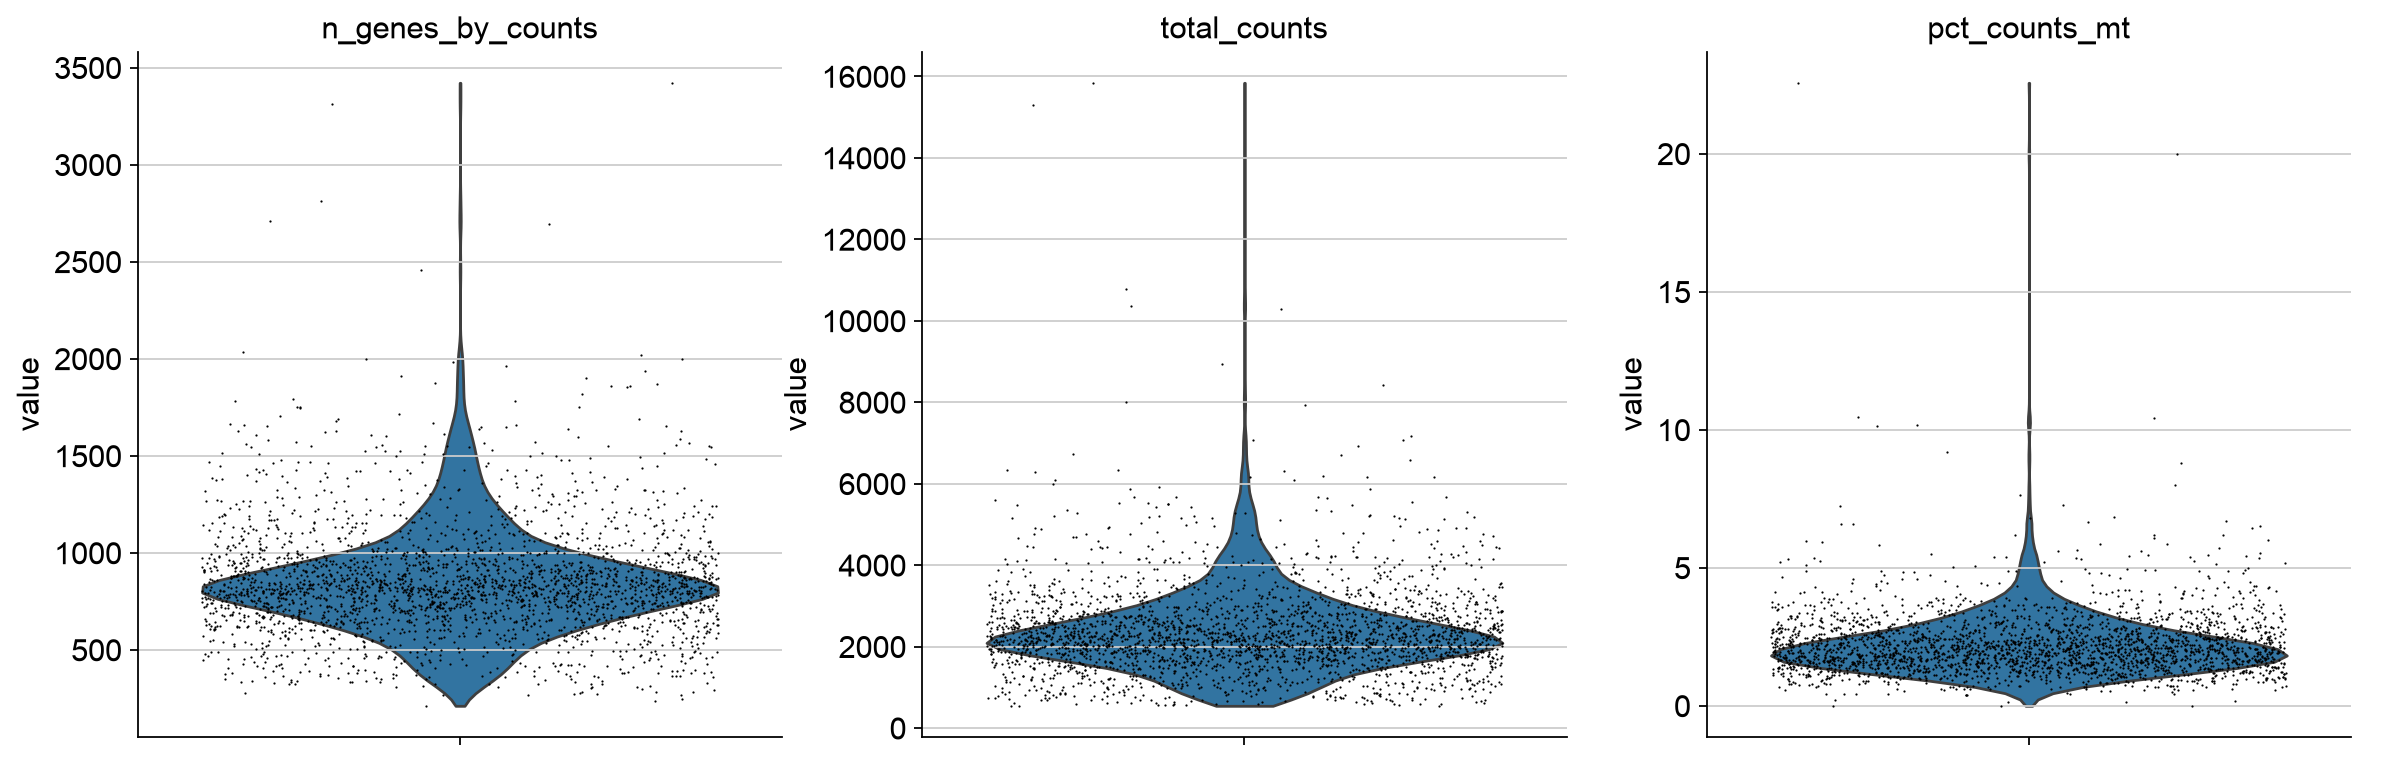

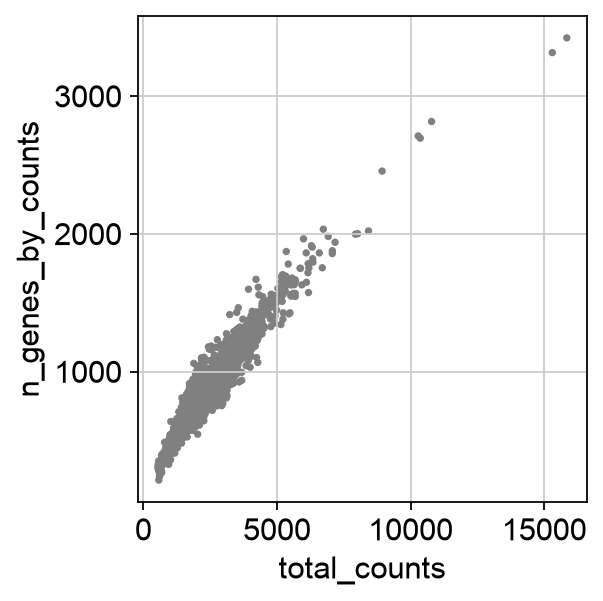

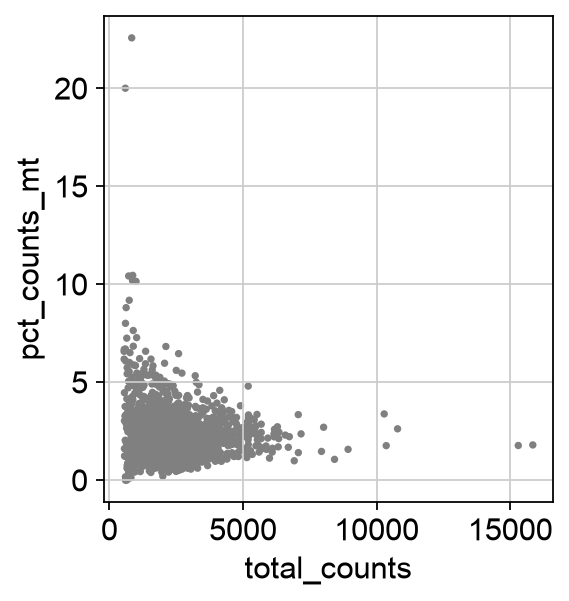

In [5]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")

**Stop and look at the plots.** Where would you draw the line for "too few genes detected"?
For "too much mitochondrial content"? There's no universally correct threshold — it depends on the
tissue, the protocol, and how conservative you want to be. We'll use thresholds that are standard
for PBMC data, but in your own work you should set these by looking at *your* distributions, not by
copying numbers from a tutorial.

## 3. Filter low-quality cells

We'll drop cells with too few or implausibly many detected genes (the latter can indicate
doublets), and cells with high mitochondrial content.

In [6]:
n_before = adata.n_obs

adata = adata[adata.obs.n_genes_by_counts > 200, :]
adata = adata[adata.obs.n_genes_by_counts < 2000, :]
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

print(f"{n_before} cells -> {adata.n_obs} cells after QC filtering "
      f"({n_before - adata.n_obs} removed)")

2700 cells -> 2634 cells after QC filtering (66 removed)


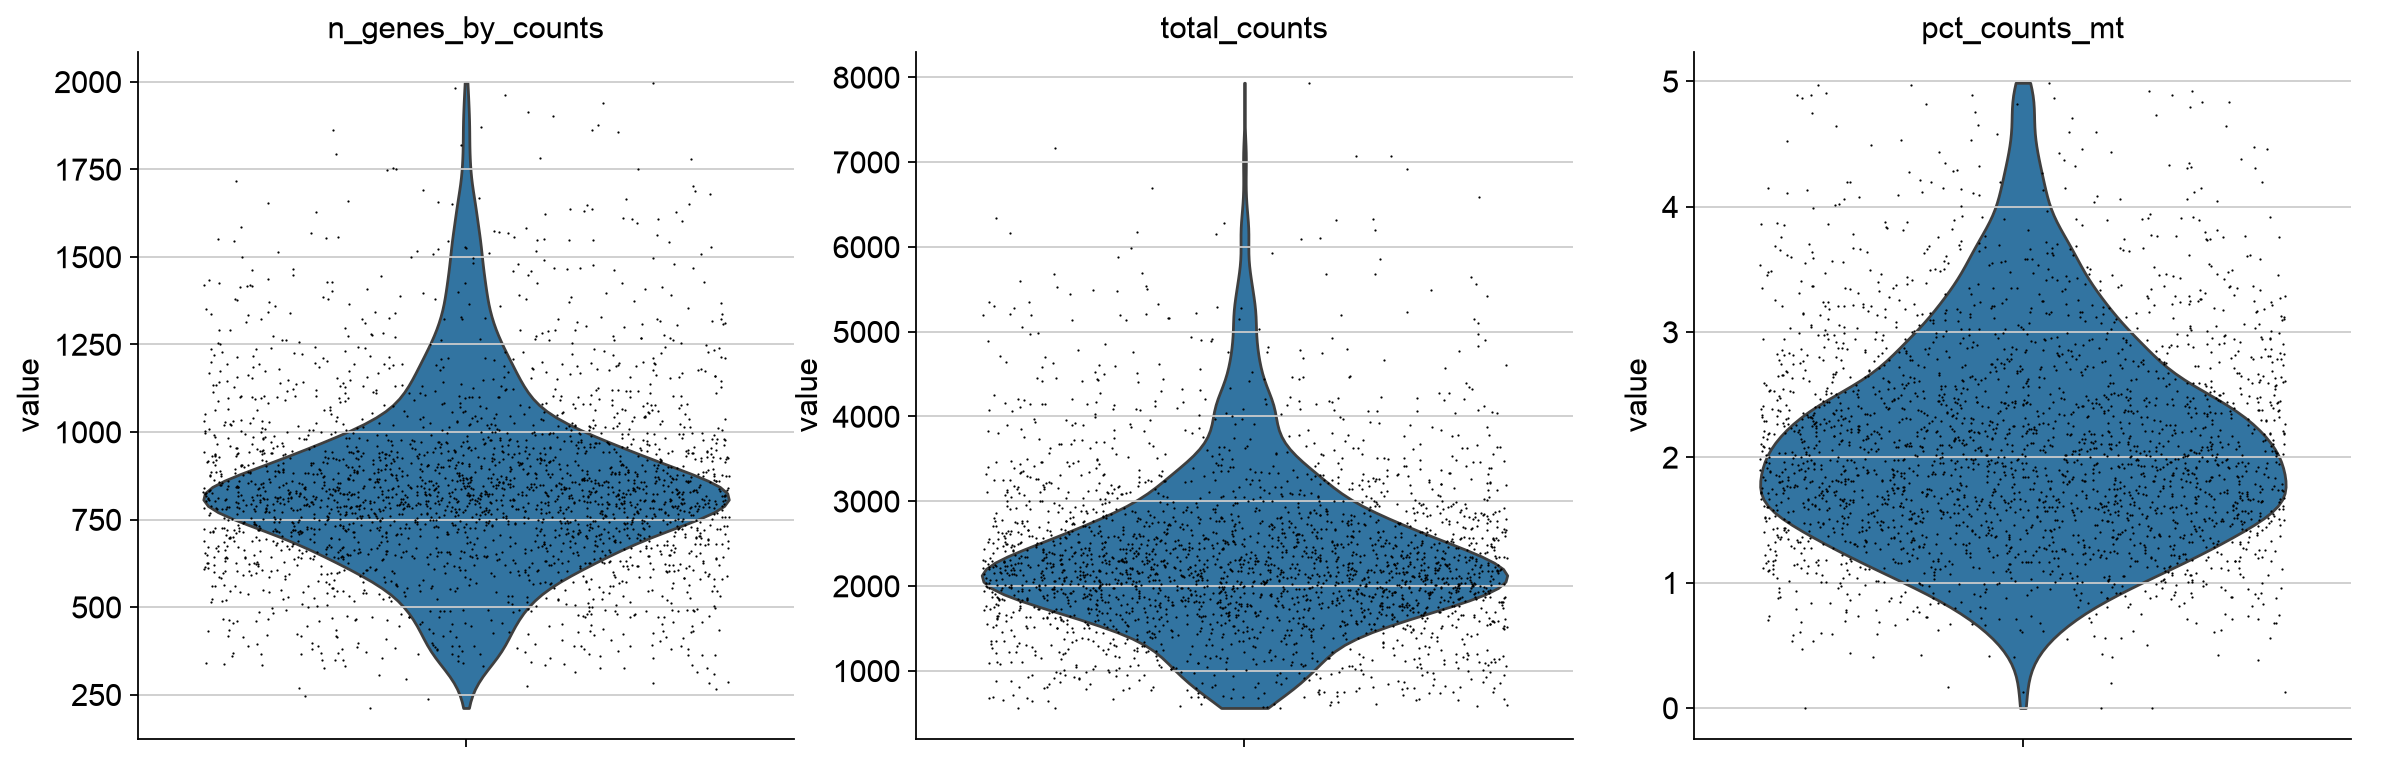

In [7]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

## 4. Save the QC'd data

We save this filtered-but-not-yet-normalized AnnData so later notebooks can pick up from here
without re-running QC. Notebook 02 will normalize and cluster it; notebook 03 (the foundation model
notebook) needs the **raw counts** of these same cells, which is why we keep `adata.raw` intact
rather than overwriting `adata.X` with normalized values here.

In [8]:
adata.write("../data/pbmc3k_qc.h5ad")
print("Saved", adata.shape)

Saved (2634, 32738)


## Recap

- scRNA-seq data is noisy and needs QC before anything else — garbage in, garbage out applies
  doubly to ML on top of it.
- `total_counts`, `n_genes_by_counts`, and `pct_counts_mt` are the standard first-pass QC metrics.
- Thresholds are dataset-specific judgment calls, not universal constants.

**Next:** `02_classical_clustering_and_annotation.ipynb` — normalize this data, cluster it, and
assign cell type labels using classical methods (PCA, Leiden clustering, marker genes).